# Learned Absolute Positional Embeddings (BERT / GPT-2 Era)

After the original transformer's fixed sinusoidal encoding, the next idea was simple:
**why not let the model learn the position embeddings?**

This notebook covers:
1. How learned PE works — it's just a lookup table
2. Visualizing what the model actually learns
3. Comparing learned vs sinusoidal PE
4. The hard ceiling problem — why this can't scale

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

## Part 1: What Is Learned Positional Embedding?

In the original transformer, PE was a fixed mathematical function (sin/cos).
BERT and GPT-2 replaced this with a **learnable embedding table**:

```python
self.position_embeddings = nn.Embedding(max_position, d_model)
```

This is literally a matrix of shape `(max_seq_len, d_model)` — one learned vector per position.
During training, backpropagation adjusts these vectors to encode whatever positional patterns
are useful for the task.

The forward pass is identical to sinusoidal PE:
```
output = token_embedding + position_embedding
```

Let's build one:

In [2]:
class LearnedPositionalEmbedding(nn.Module):
    def __init__(self, max_seq_len, d_model):
        super().__init__()
        # This is the entire thing — just a lookup table
        self.position_embeddings = nn.Embedding(max_seq_len, d_model)
    
    def forward(self, seq_len):
        positions = torch.arange(seq_len)
        return self.position_embeddings(positions)  # (seq_len, d_model)

# Compare sizes
max_len = 512  # BERT's limit
d_model = 64

learned_pe = LearnedPositionalEmbedding(max_len, d_model)
print(f"Learned PE: {max_len} positions × {d_model} dims = {max_len * d_model:,} parameters")
print(f"Sinusoidal PE: 0 parameters (computed from formula)")
print()
print(f"For BERT (512 × 768): {512 * 768:,} extra parameters just for position")
print(f"For GPT-2 (1024 × 768): {1024 * 768:,} extra parameters just for position")
print()

# Before training — random initialization
pe_before = learned_pe(max_len).detach()
print(f"Before training, PE[0][:8] = {pe_before[0, :8].numpy().round(3)}")
print(f"Before training, PE[1][:8] = {pe_before[1, :8].numpy().round(3)}")
print("(Random — no structure yet)")

Learned PE: 512 positions × 64 dims = 32,768 parameters
Sinusoidal PE: 0 parameters (computed from formula)

For BERT (512 × 768): 393,216 extra parameters just for position
For GPT-2 (1024 × 768): 786,432 extra parameters just for position

Before training, PE[0][:8] = [ 0.329  0.725  0.188  0.916 -2.901  0.137 -0.095 -0.106]
Before training, PE[1][:8] = [ 0.475 -1.703  1.012 -0.278 -0.319 -0.495  0.451 -0.355]
(Random — no structure yet)


## Part 2: What Does the Model Learn?

We can't train a full BERT here, but we can simulate what happens: train a tiny model
on a task that requires position awareness, and watch the PE evolve.

Task: predict which **position** a token is at (a toy task that forces the PE to encode position).


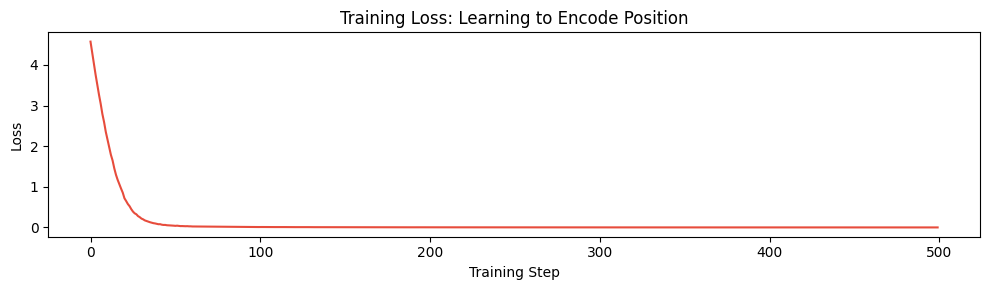

Final loss: 0.0009 (random chance would be 4.16)


In [3]:
torch.manual_seed(42)

max_len = 64
d_model = 32
vocab_size = 100

# Tiny model: embedding + learned PE + linear classifier to predict position
class TinyPositionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(max_len, d_model)
        self.classifier = nn.Linear(d_model, max_len)
    
    def forward(self, tokens):
        seq_len = tokens.shape[1]
        positions = torch.arange(seq_len)
        x = self.token_emb(tokens) + self.pos_emb(positions)
        return self.classifier(x)  # predict position from combined embedding

model = TinyPositionModel()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Train: random tokens, target = position index
losses = []
for step in range(500):
    tokens = torch.randint(0, vocab_size, (16, max_len))  # batch of 16
    targets = torch.arange(max_len).unsqueeze(0).expand(16, -1)
    
    logits = model(tokens)
    loss = F.cross_entropy(logits.view(-1, max_len), targets.reshape(-1))
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(losses, color='#e74c3c', linewidth=1.5)
ax.set_xlabel('Training Step')
ax.set_ylabel('Loss')
ax.set_title('Training Loss: Learning to Encode Position')
plt.tight_layout()
plt.show()
print(f"Final loss: {losses[-1]:.4f} (random chance would be {np.log(max_len):.2f})")

### Visualizing the learned position embeddings

Now let's look at what the model actually learned — compare the structure of the
learned PE matrix vs the sinusoidal one:

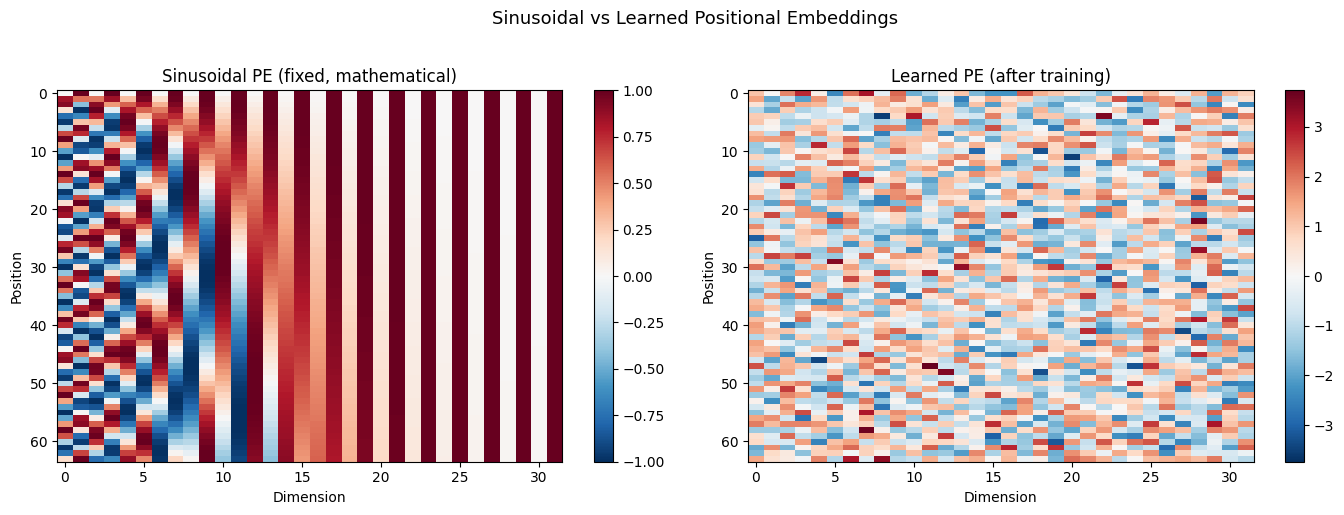

The learned PE often develops sinusoidal-like patterns!
This suggests the sinusoidal structure is a good inductive bias,
but the learned version can also capture task-specific patterns.


In [4]:
def sinusoidal_pe(max_len, d_model):
    pe = torch.zeros(max_len, d_model)
    position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float) * (-np.log(10000.0) / d_model))
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe

learned = model.pos_emb.weight.detach()
sinusoidal = sinusoidal_pe(max_len, d_model)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im0 = axes[0].imshow(sinusoidal.numpy(), aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
axes[0].set_title('Sinusoidal PE (fixed, mathematical)')
axes[0].set_xlabel('Dimension')
axes[0].set_ylabel('Position')
plt.colorbar(im0, ax=axes[0])

vmax = learned.abs().max().item()
im1 = axes[1].imshow(learned.numpy(), aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
axes[1].set_title('Learned PE (after training)')
axes[1].set_xlabel('Dimension')
axes[1].set_ylabel('Position')
plt.colorbar(im1, ax=axes[1])

plt.suptitle('Sinusoidal vs Learned Positional Embeddings', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("The learned PE often develops sinusoidal-like patterns!")
print("This suggests the sinusoidal structure is a good inductive bias,")
print("but the learned version can also capture task-specific patterns.")

### Cosine similarity: do nearby positions look similar?

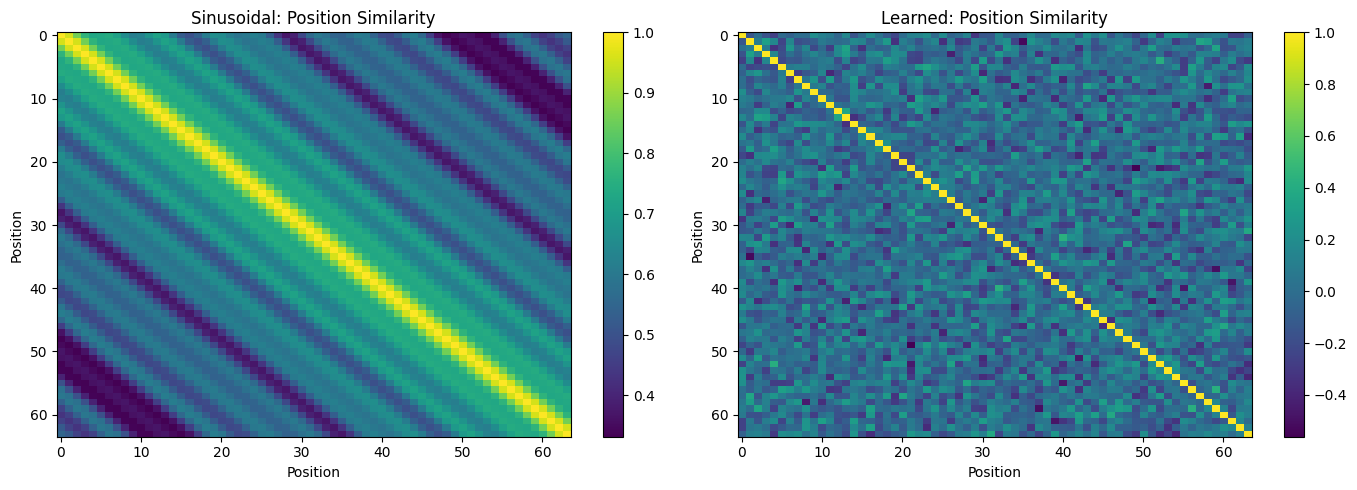

Both show the key property: nearby positions are more similar.
But the learned version may have sharper or more irregular patterns.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sinusoidal similarity
sin_norm = sinusoidal / sinusoidal.norm(dim=1, keepdim=True)
sin_sim = sin_norm @ sin_norm.T

# Learned similarity
lrn_norm = learned / learned.norm(dim=1, keepdim=True)
lrn_sim = lrn_norm @ lrn_norm.T

im0 = axes[0].imshow(sin_sim.numpy(), cmap='viridis', aspect='auto')
axes[0].set_title('Sinusoidal: Position Similarity')
axes[0].set_xlabel('Position')
axes[0].set_ylabel('Position')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(lrn_sim.numpy(), cmap='viridis', aspect='auto')
axes[1].set_title('Learned: Position Similarity')
axes[1].set_xlabel('Position')
axes[1].set_ylabel('Position')
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()

print("Both show the key property: nearby positions are more similar.")
print("But the learned version may have sharper or more irregular patterns.")

## Part 3: The Hard Ceiling Problem

This is the fatal flaw of learned PE. Let's see it in action:

In [6]:
# Model was trained with max_len = 64
# What happens if we try position 64 (one beyond)?

print("Our model's PE table has positions 0 to 63.")
print(f"PE table shape: {model.pos_emb.weight.shape}")
print()

try:
    pos_65 = model.pos_emb(torch.tensor([64]))
    print("Position 64:", pos_65)
except IndexError as e:
    print(f"ERROR: {e}")
    print()
    print("Position 64 does not exist! The embedding table only has 64 rows.")
    print("This is a HARD CRASH, not a graceful degradation.")
    print()
    print("Compare with sinusoidal PE:")
    sin_pe_65 = sinusoidal_pe(65, d_model)[-1]
    print(f"  Sinusoidal PE[64] = {sin_pe_65[:8].numpy().round(3)} ... (works fine!)")
    print()
    print("Sinusoidal PE can compute ANY position from the formula.")
    print("Learned PE is limited to positions it has parameters for.")

Our model's PE table has positions 0 to 63.
PE table shape: torch.Size([64, 32])

ERROR: index out of range in self

Position 64 does not exist! The embedding table only has 64 rows.
This is a HARD CRASH, not a graceful degradation.

Compare with sinusoidal PE:
  Sinusoidal PE[64] = [ 0.92   0.392 -0.99  -0.138  0.984  0.181 -0.927  0.376] ... (works fine!)

Sinusoidal PE can compute ANY position from the formula.
Learned PE is limited to positions it has parameters for.


### The scaling comparison

| Method | Max Context | Extrapolation | Parameters |
|--------|------------|---------------|------------|
| Sinusoidal PE | Unlimited (in theory) | Mathematically valid, but model doesn't generalize | 0 |
| Learned PE (BERT) | 512 | **Crashes** — position doesn't exist | 393,216 |
| Learned PE (GPT-2) | 1024 | **Crashes** — position doesn't exist | 786,432 |

Both approaches fail at scaling, but for different reasons:
- Sinusoidal: the PE values exist but the model's learned attention patterns don't generalize
- Learned: the PE values **literally don't exist** beyond the table size

This is why the field moved to **relative positional encodings** — they encode the
*distance between tokens* rather than absolute position, which naturally generalizes better.

Next: **RoPE — Rotary Position Embedding** (the method that solved this problem) 🚀